# Final Visualizations ? IoT Botnet LDO Evaluation

Publication-quality visualizations for the final comparison of Ensemble, CNN, and Autoencoder detectors under random-split and Leave-Device-Out (LDO) evaluation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
RESULTS = PROJECT_ROOT / 'results' / 'raw_metrics.csv'
FIGURES = PROJECT_ROOT / 'docs' / 'milestone-7' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RESULTS)

assert len(df) == 126, f'Expected 126 rows, found {len(df)}'
assert not df.duplicated(['dataset', 'split_type', 'model', 'fold', 'random_state']).any(), 'Duplicate experiment keys found'

print(f'Validated {len(df)} experiment rows.')
print(f'Datasets: {sorted(df.dataset.unique())}')
print(f'Models: {sorted(df.model.unique())}')
print(f'Splits: {sorted(df.split_type.unique())}')

Validated 126 experiment rows.
Datasets: ['medbiot', 'nbaiot']
Models: ['autoencoder', 'cnn', 'ensemble']
Splits: ['ldo', 'random']


## Final Summary Statistics

Means and standard deviations are calculated across all experiment rows for each dataset, model, and evaluation protocol. For random splits this corresponds to three seeds; for LDO it includes all device/device-type folds and three seeds per fold.

In [2]:
metrics = ['accuracy', 'macro_f1', 'fpr']

summary = (
    df.groupby(['dataset', 'split_type', 'model'])[metrics]
      .agg(['mean', 'std'])
      .reset_index()
)

summary.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in summary.columns
]

summary = summary.sort_values(['dataset', 'split_type', 'model'])
summary.to_csv(PROJECT_ROOT / 'results' / 'final_summary_stats.csv', index=False)
summary

,dataset,split_type,model,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,fpr_mean,fpr_std
0,medbiot,ldo,autoencoder,0.832111,0.053415,0.828419,0.059667,0.053811,0.005661
1,medbiot,ldo,cnn,0.957903,0.013764,0.957834,0.013844,0.010172,0.006670
2,medbiot,ldo,ensemble,0.986106,0.014143,0.986095,0.014159,0.003211,0.002154
3,medbiot,random,autoencoder,0.848550,0.006222,0.847020,0.006404,0.051617,0.002928
4,medbiot,random,cnn,0.962175,0.000524,0.962135,0.000522,0.005517,0.001928
5,medbiot,random,ensemble,0.998683,0.000406,0.998683,0.000406,0.000833,0.000321
6,nbaiot,ldo,autoencoder,0.956083,0.049781,0.940752,0.060935,0.124043,0.126761
7,nbaiot,ldo,cnn,0.996698,0.007514,0.996088,0.008923,0.009243,0.023736
8,nbaiot,ldo,ensemble,0.998331,0.003675,0.998089,0.004263,0.004632,0.011515
9,nbaiot,random,autoencoder,0.979158,0.000389,0.976810,0.000436,0.050744,0.000857


## Figure 1 ? Generalization Gap

Macro-F1 is used as the primary comparison metric. Each dataset/model combination shows random-split performance and LDO performance side by side.

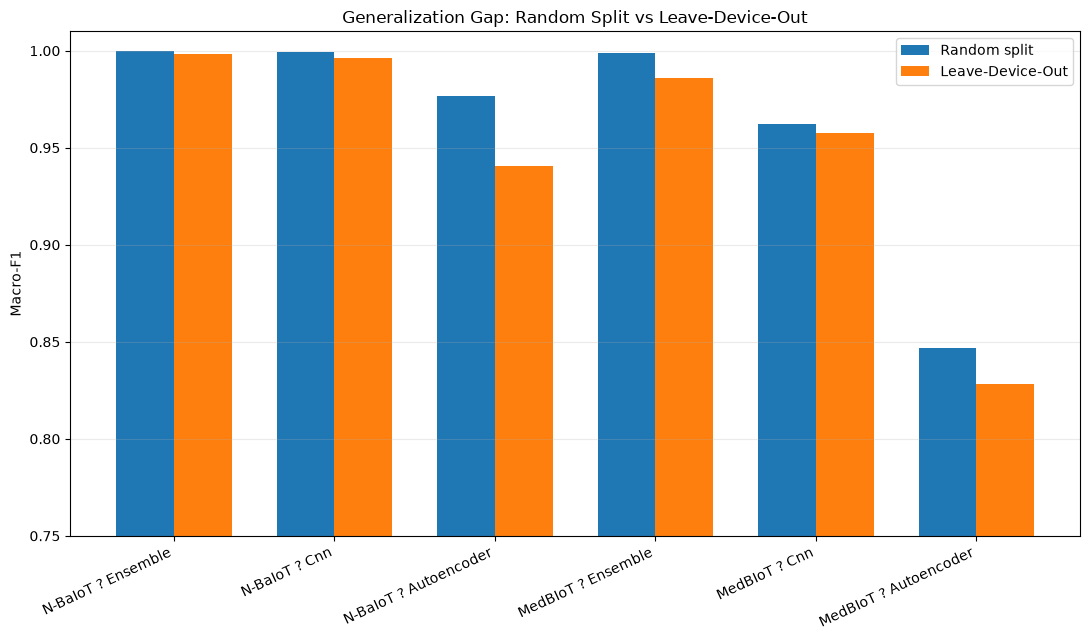

In [3]:
plot_df = summary.copy()
plot_df['label'] = plot_df['dataset'].map({'nbaiot': 'N-BaIoT', 'medbiot': 'MedBIoT'}) + ' ? ' + plot_df['model'].str.title()

order = [
    'N-BaIoT ? Ensemble', 'N-BaIoT ? Cnn', 'N-BaIoT ? Autoencoder',
    'MedBIoT ? Ensemble', 'MedBIoT ? Cnn', 'MedBIoT ? Autoencoder'
]

pivot = plot_df.pivot(index='label', columns='split_type', values='macro_f1_mean').reindex(order)

x = np.arange(len(pivot))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.bar(x - width / 2, pivot['random'], width, label='Random split')
ax.bar(x + width / 2, pivot['ldo'], width, label='Leave-Device-Out')

ax.set_ylabel('Macro-F1')
ax.set_title('Generalization Gap: Random Split vs Leave-Device-Out')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=25, ha='right')
ax.set_ylim(0.75, 1.01)
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()

fig.savefig(FIGURES / 'generalization_gap_macro_f1.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'generalization_gap_macro_f1.svg', bbox_inches='tight')
plt.show()
plt.close(fig)

## Figure 2 ? False Positive Rate Comparison

The N-BaIoT Autoencoder shows the clearest FPR increase under LDO evaluation, motivating the specific annotation in the figure.

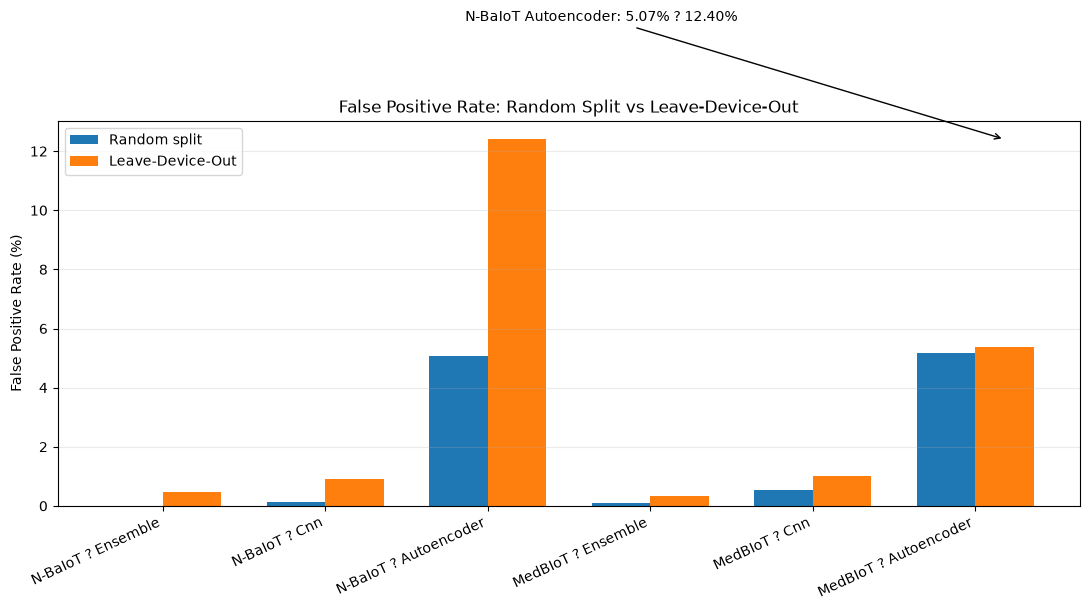

In [4]:
fpr_pivot = plot_df.pivot(index='label', columns='split_type', values='fpr_mean').reindex(order)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.bar(x - width / 2, fpr_pivot['random'] * 100, width, label='Random split')
ax.bar(x + width / 2, fpr_pivot['ldo'] * 100, width, label='Leave-Device-Out')

ax.set_ylabel('False Positive Rate (%)')
ax.set_title('False Positive Rate: Random Split vs Leave-Device-Out')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=25, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.25)

nb_auto_random = summary[(summary.dataset == 'nbaiot') & (summary.model == 'autoencoder') & (summary.split_type == 'random')]['fpr_mean'].iloc[0] * 100
nb_auto_ldo = summary[(summary.dataset == 'nbaiot') & (summary.model == 'autoencoder') & (summary.split_type == 'ldo')]['fpr_mean'].iloc[0] * 100

ax.annotate(
    f'N-BaIoT Autoencoder: {nb_auto_random:.2f}% ? {nb_auto_ldo:.2f}%',
    xy=(5 + width / 2, nb_auto_ldo),
    xytext=(2.7, max(nb_auto_ldo + 4, 15)),
    arrowprops=dict(arrowstyle='->'),
    fontsize=10,
    ha='center'
)

fig.tight_layout()
fig.savefig(FIGURES / 'fpr_comparison.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'fpr_comparison.svg', bbox_inches='tight')
plt.show()
plt.close(fig)

## Figure 3 ? LDO Degradation in Macro-F1

Degradation is defined as Random Split Macro-F1 minus LDO Macro-F1. Positive values indicate lower performance under unseen-device evaluation.

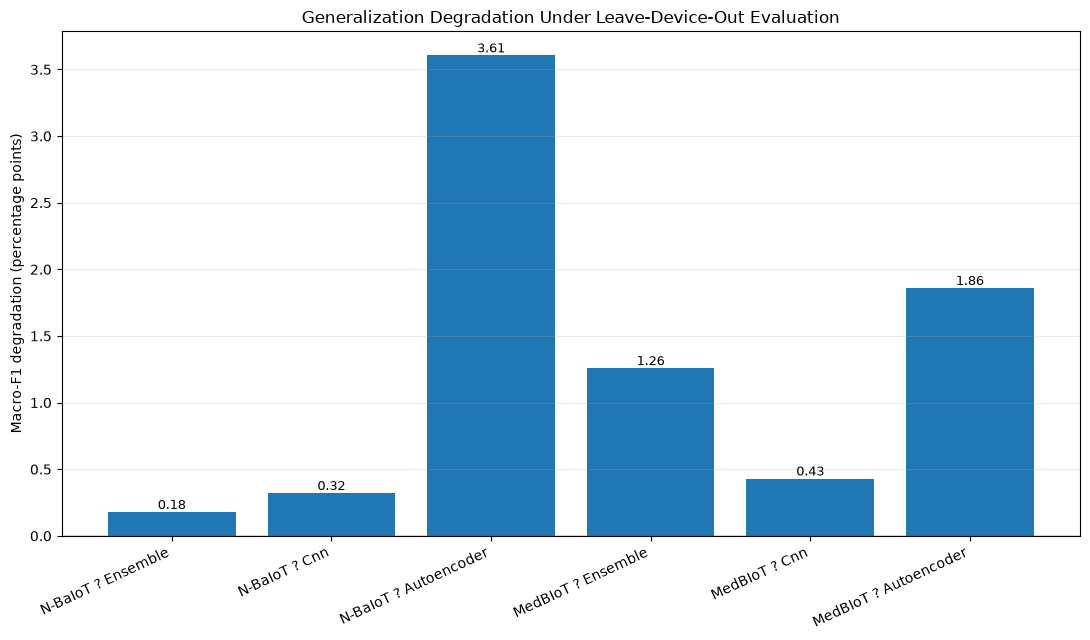

In [5]:
random_mf1 = summary[summary.split_type == 'random'][['dataset', 'model', 'macro_f1_mean']].rename(columns={'macro_f1_mean': 'random_macro_f1'})
ldo_mf1 = summary[summary.split_type == 'ldo'][['dataset', 'model', 'macro_f1_mean']].rename(columns={'macro_f1_mean': 'ldo_macro_f1'})
delta = random_mf1.merge(ldo_mf1, on=['dataset', 'model'])
delta['degradation'] = delta['random_macro_f1'] - delta['ldo_macro_f1']
delta['label'] = delta['dataset'].map({'nbaiot': 'N-BaIoT', 'medbiot': 'MedBIoT'}) + ' ? ' + delta['model'].str.title()
delta = delta.set_index('label').reindex(order).reset_index()

fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.bar(np.arange(len(delta)), delta['degradation'] * 100)

ax.axhline(0, linewidth=1)
ax.set_ylabel('Macro-F1 degradation (percentage points)')
ax.set_title('Generalization Degradation Under Leave-Device-Out Evaluation')
ax.set_xticks(np.arange(len(delta)))
ax.set_xticklabels(delta['label'], rotation=25, ha='right')
ax.grid(axis='y', alpha=0.25)

for bar, value in zip(bars, delta['degradation'] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{value:.2f}', ha='center', va='bottom', fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES / 'degradation_delta_macro_f1.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES / 'degradation_delta_macro_f1.svg', bbox_inches='tight')
plt.show()
plt.close(fig)

## Statistical Interpretation

The final analysis reports means and observed standard deviations rather than treating SD separation as a formal significance test. Random-split results contain three seeds per model/dataset, while LDO results aggregate across device or device-type folds and three seeds per fold. Therefore, the variability estimates describe experimental dispersion and should not be interpreted as independent identically distributed replicates.

For the Ensemble-versus-CNN comparison, the N-BaIoT LDO gap is small relative to the combined observed standard deviations, whereas the MedBIoT gap is approximately equal to and marginally larger than the combined SDs. This is reported as effect-size/variability evidence, not as formal statistical significance.

In [6]:
print('Generated summary: results/final_summary_stats.csv')
print('Generated figures:')
for path in sorted(FIGURES.glob('*')):
    print(' -', path.relative_to(PROJECT_ROOT))

Generated summary: results/final_summary_stats.csv
Generated figures:
 - docs\milestone-7\figures\degradation_delta_macro_f1.png
 - docs\milestone-7\figures\degradation_delta_macro_f1.svg
 - docs\milestone-7\figures\fpr_comparison.png
 - docs\milestone-7\figures\fpr_comparison.svg
 - docs\milestone-7\figures\generalization_gap_macro_f1.png
 - docs\milestone-7\figures\generalization_gap_macro_f1.svg
